I. Analyzing Reproductive Health and Behavior Patterns Using NSFG 2022–2023

# Task 1

In [7]:
library(tidyverse) 
library(MASS)      
library(nnet)      
library(vcd)       
library(AER)      


fem_raw <- read.csv("/kaggle/input/datasets/ivancobarrubias/sa2-dsc1105/NSFG_2022_2023_FemRespPUFData.csv", stringsAsFactors = FALSE)



# Task 2&3

In [10]:
# Clean Female Respondent Data using official 2022-2023 variable names
fem_clean <- fem_raw %>%
  # FIX: Explicitly tell R to use the dplyr version of select
  dplyr::select(PARITY, GENHEALT, AGER, HIEDUC, RMARITAL) %>%
  
  # Filter out "Refused" or "Don't Know" codes 
  filter(GENHEALT < 8, RMARITAL < 9) %>% 
  
  mutate(
    # Ordered Categorical: General Health 
    HealthStatus = factor(GENHEALT, levels = c(5,4,3,2,1), 
                          labels = c("Poor", "Fair", "Good", "Very Good", "Excellent"), 
                          ordered = TRUE),
    
    # Nominal Categorical: Marital Status
    MaritalStatus = factor(RMARITAL, levels = 1:6, 
                           labels = c("Married", "Cohabiting", "Widowed", 
                                      "Divorced", "Separated", "Never Married")),
    
    # Demographic: Education (NSFG codes 9=Less than HS, 10=HS, 11=Some college, 12=Bachelors+)
    EducationGroup = factor(case_when(
      HIEDUC <= 10 ~ "High School or Less",
      HIEDUC == 11 ~ "Some College",
      HIEDUC == 12 ~ "Bachelor's+"
    ), levels = c("High School or Less", "Some College", "Bachelor's+"))
  ) %>% 
  
  # Drop any remaining NAs to ensure all models run on the exact same sample size
  drop_na()

print(paste("Total valid cases:", nrow(fem_clean)))

[1] "Cleaned dataset is ready! Total valid cases: 5547"


# TASK 4A: POISSON REGRESSION

In [11]:
# Fit the model
poisson_model <- glm(PARITY ~ AGER + EducationGroup, family = "poisson", data = fem_clean)
print(summary(poisson_model))

# Check Assumption: Mean vs Variance (Overdispersion)
print("--- Overdispersion Check ---")
print(dispersiontest(poisson_model))


Call:
glm(formula = PARITY ~ AGER + EducationGroup, family = "poisson", 
    data = fem_clean)

Coefficients:
                           Estimate Std. Error z value Pr(>|z|)    
(Intercept)                -2.12025    0.05853 -36.224   <2e-16 ***
AGER                        0.06238    0.00152  41.029   <2e-16 ***
EducationGroupSome College -0.23578    0.10195  -2.313   0.0207 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 10046.9  on 5546  degrees of freedom
Residual deviance:  8193.1  on 5544  degrees of freedom
AIC: 15214

Number of Fisher Scoring iterations: 6

[1] "--- Overdispersion Check ---"

	Overdispersion test

data:  poisson_model
z = 11.668, p-value < 2.2e-16
alternative hypothesis: true dispersion is greater than 1
sample estimates:
dispersion 
  1.609793 



# TASK 4B: CONTINGENCY TABLES

               
                Poor Fair Good Very Good Excellent
  Married         28  148  603       828       441
  Cohabiting       6   68  218       216       116
  Widowed          1    4    8         5         5
  Divorced         8   30   98        99        45
  Separated       10    9   37        21        16
  Never Married   56  252  763       857       551


Warning message in chisq.test(cont_table):
“Chi-squared approximation may be incorrect”



	Pearson's Chi-squared test

data:  cont_table
X-squared = 96.156, df = 20, p-value = 6.099e-12



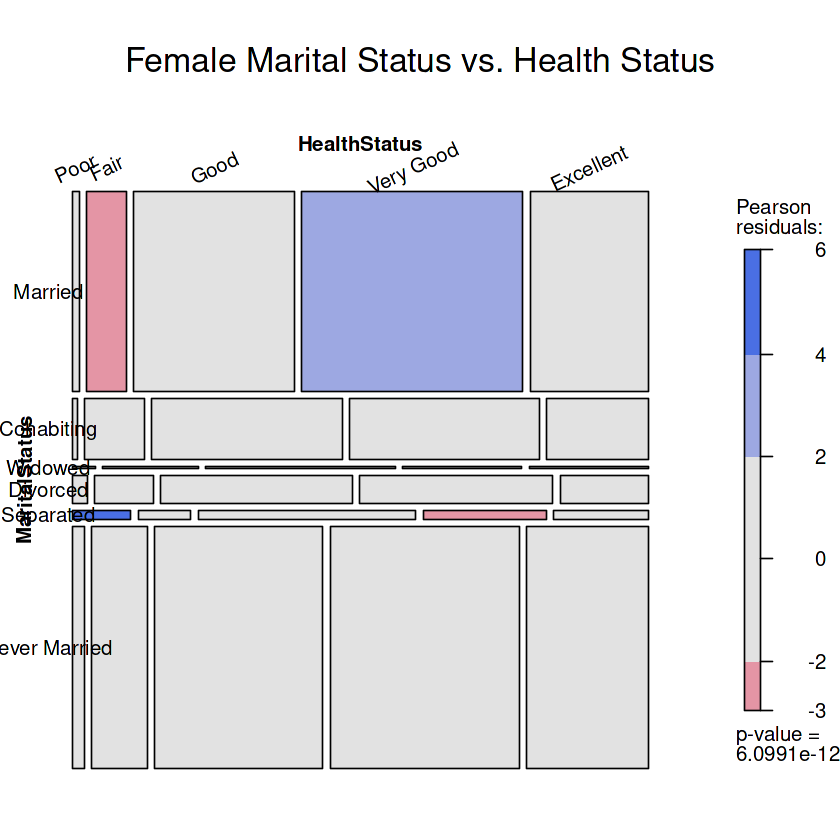

In [12]:
cont_table <- table(fem_clean$MaritalStatus, fem_clean$HealthStatus)
print(cont_table)

# Chi-square test
chisq_res <- chisq.test(cont_table)
print(chisq_res)

# (This will appear in your RStudio Plots pane)
mosaic(~ MaritalStatus + HealthStatus, data = fem_clean, shade = TRUE, 
       main = "Female Marital Status vs. Health Status",
       labeling_args = list(rot_labels = c(left = 0, top = 25)),
       margins = c(bottom = 3, left = 3, top = 3, right = 3))

# TASK 4C: CATEGORICAL RESPONSE MODELING

In [13]:
# 1. Ordinal Logistic Regression (Ordered Outcome)
print("--- Ordinal Model: Predicting Health Status ---")
ord_model <- polr(HealthStatus ~ AGER + MaritalStatus, data = fem_clean, Hess = TRUE)
print(summary(ord_model))
print("--- Exponentiated Odds Ratios (Ordinal) ---")
print(exp(coef(ord_model))) 

# 2. Multinomial Logistic Regression (Unordered Outcome)
print("--- Multinomial Model: Predicting Marital Status ---")
# Set baseline to 'Never Married' for easier interpretation
fem_clean$MaritalStatus <- relevel(fem_clean$MaritalStatus, ref = "Never Married")
multinom_model <- multinom(MaritalStatus ~ AGER + EducationGroup, data = fem_clean)
print(summary(multinom_model))
print("--- Exponentiated Odds Ratios (Multinomial) ---")
print(exp(coef(multinom_model)))

[1] "--- Ordinal Model: Predicting Health Status ---"
Call:
polr(formula = HealthStatus ~ AGER + MaritalStatus, data = fem_clean, 
    Hess = TRUE)

Coefficients:
                             Value Std. Error t value
AGER                       -0.0231   0.003051  -7.570
MaritalStatusCohabiting    -0.4075   0.084088  -4.846
MaritalStatusWidowed       -0.5129   0.403361  -1.271
MaritalStatusDivorced      -0.3327   0.115787  -2.874
MaritalStatusSeparated     -0.8405   0.200205  -4.198
MaritalStatusNever Married -0.3909   0.062664  -6.238

Intercepts:
                    Value    Std. Error t value 
Poor|Fair            -4.9382   0.1558   -31.7055
Fair|Good            -3.0927   0.1283   -24.1020
Good|Very Good       -1.3102   0.1216   -10.7722
Very Good|Excellent   0.3327   0.1208     2.7546

Residual Deviance: 14957.24 
AIC: 14977.24 
[1] "--- Exponentiated Odds Ratios (Ordinal) ---"
                      AGER    MaritalStatusCohabiting 
                 0.9771643                  0.66530

Warning message in sqrt(diag(vc)):
“NaNs produced”


Call:
multinom(formula = MaritalStatus ~ AGER + EducationGroup, data = fem_clean)

Coefficients:
           (Intercept)       AGER EducationGroupSome College
Married      -4.728551 0.13995594                  1.3190516
Cohabiting   -3.370288 0.06711325                  0.6607996
Widowed     -15.023232 0.28211128                  1.6700170
Divorced     -9.092643 0.20114034                  0.9135858
Separated    -7.736244 0.13822486                  0.2673097
           EducationGroupBachelor's+
Married                            0
Cohabiting                         0
Widowed                            0
Divorced                           0
Separated                          0

Std. Errors:
           (Intercept)        AGER EducationGroupSome College
Married      0.1468481 0.004349348                  0.3396949
Cohabiting   0.1710723 0.005325283                  0.4694827
Widowed      1.7598285 0.040338641                  1.0788048
Divorced     0.3881780 0.009765318                  0

# TASK 4D: EXPLORATORY DATA ANALYSIS & MULTIPLE COMPARISONS

[1] "--- ANOVA Results ---"
                Df Sum Sq Mean Sq F value Pr(>F)    
MaritalStatus    5 140532   28106   428.6 <2e-16 ***
Residuals     5541 363350      66                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
[1] "--- Pairwise Age Comparisons by Marital Status (FDR Adjusted) ---"

	Pairwise comparisons using t tests with pooled SD 

data:  fem_clean$AGER and fem_clean$MaritalStatus 

           Never Married Married Cohabiting Widowed Divorced
Married    < 2e-16       -       -          -       -       
Cohabiting < 2e-16       < 2e-16 -          -       -       
Widowed    < 2e-16       0.00042 1.1e-10    -       -       
Divorced   < 2e-16       4.5e-10 < 2e-16    0.11011 -       
Separated  < 2e-16       0.86911 4.4e-08    0.00102 0.00055 

P value adjustment method: fdr 


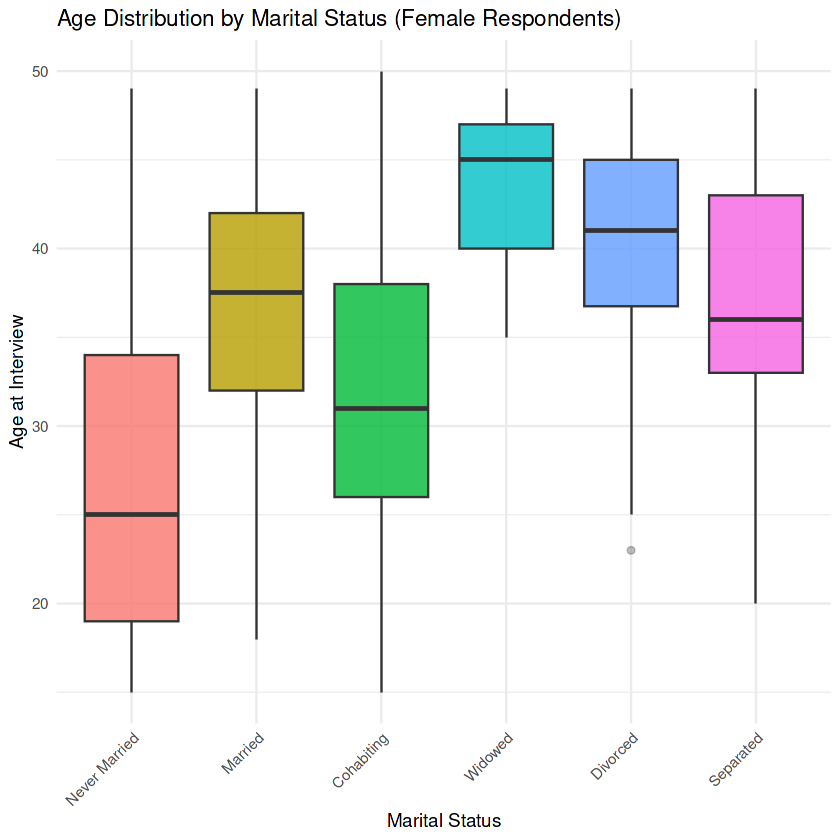

In [14]:
# 1. EDA Visualization: Boxplots across Marital Status
plot_eda <- ggplot(fem_clean, aes(x = MaritalStatus, y = AGER, fill = MaritalStatus)) +
  geom_boxplot(alpha = 0.8, outlier.alpha = 0.3) +
  theme_minimal() +
  labs(title = "Age Distribution by Marital Status (Female Respondents)", 
       x = "Marital Status", y = "Age at Interview") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1),
        legend.position = "none") # Hide legend since the x-axis is already labeled

# Print the plot to the viewing pane
print(plot_eda)

# 2. ANOVA: Does age differ by Marital Status?
print("--- ANOVA Results ---")
anova_fem <- aov(AGER ~ MaritalStatus, data = fem_clean)
print(summary(anova_fem))

# 3. Multiple Comparisons with False Discovery Rate (FDR) adjustment
print("--- Pairwise Age Comparisons by Marital Status (FDR Adjusted) ---")
fdr_tests <- pairwise.t.test(fem_clean$AGER, fem_clean$MaritalStatus, p.adjust.method = "fdr")
print(fdr_tests)

II. Principal Component Analysis of TF-IDF Article Data

In [15]:
library(ggplot2)
library(dplyr)
library(ggrepel)

In [17]:
df <- read.csv("/kaggle/input/datasets/ivancobarrubias/sa2-dsc1105/nyt_articles-1.csv", stringsAsFactors = FALSE)

# Identify the categorical column (Article Type)
# Assuming it's the first character/factor column (adjust if named specifically, e.g., 'class')
cat_col_name <- names(df)[sapply(df, function(x) is.character(x) | is.factor(x))][1]
article_labels <- df[[cat_col_name]]

# Extract only the numeric columns (TF-IDF word frequencies)
num_data <- df[, sapply(df, is.numeric)]

# Remove columns with zero variance (words that are exactly the same across all docs)
# This is necessary for PCA to run without errors.
variances <- apply(num_data, 2, var)
num_data <- num_data[, variances > 0]

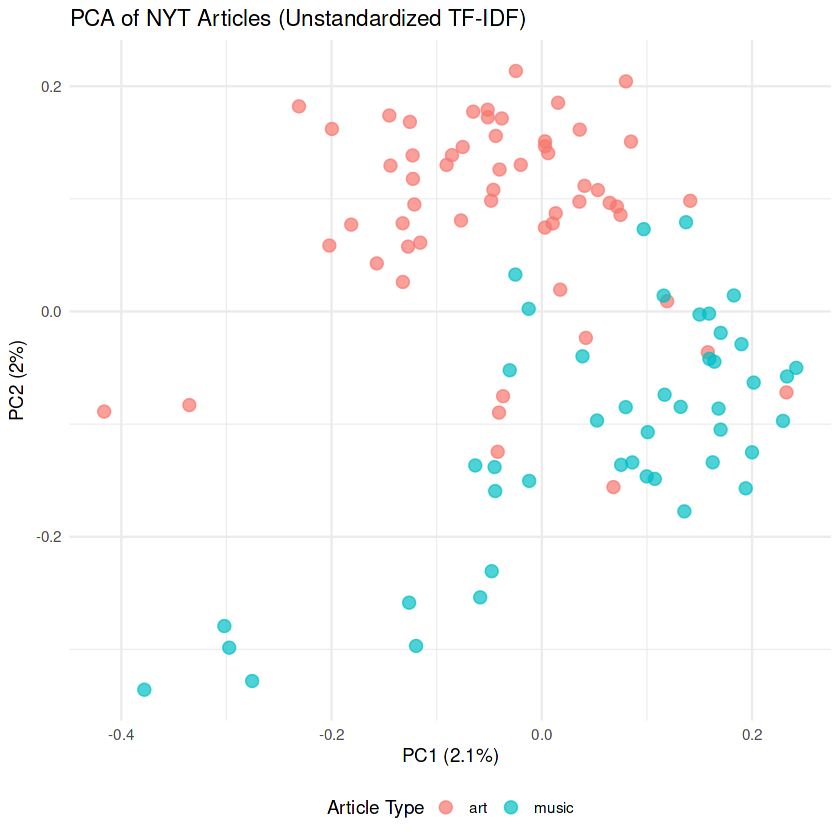

In [18]:
pca_result <- prcomp(num_data, center = TRUE, scale. = FALSE)

# Create a dataframe for the scores (the coordinates of the articles)
pca_data <- data.frame(
  PC1 = pca_result$x[, 1],
  PC2 = pca_result$x[, 2],
  Article_Type = article_labels
)

# Plot 1: PCA Scatter Plot
plot1 <- ggplot(pca_data, aes(x = PC1, y = PC2, color = Article_Type)) +
  geom_point(size = 3, alpha = 0.7) +
  theme_minimal() +
  labs(title = "PCA of NYT Articles (Unstandardized TF-IDF)",
       x = paste0("PC1 (", round(summary(pca_result)$importance[2,1]*100, 1), "%)"),
       y = paste0("PC2 (", round(summary(pca_result)$importance[2,2]*100, 1), "%)"),
       color = "Article Type") +
  theme(legend.position = "bottom")

print(plot1)

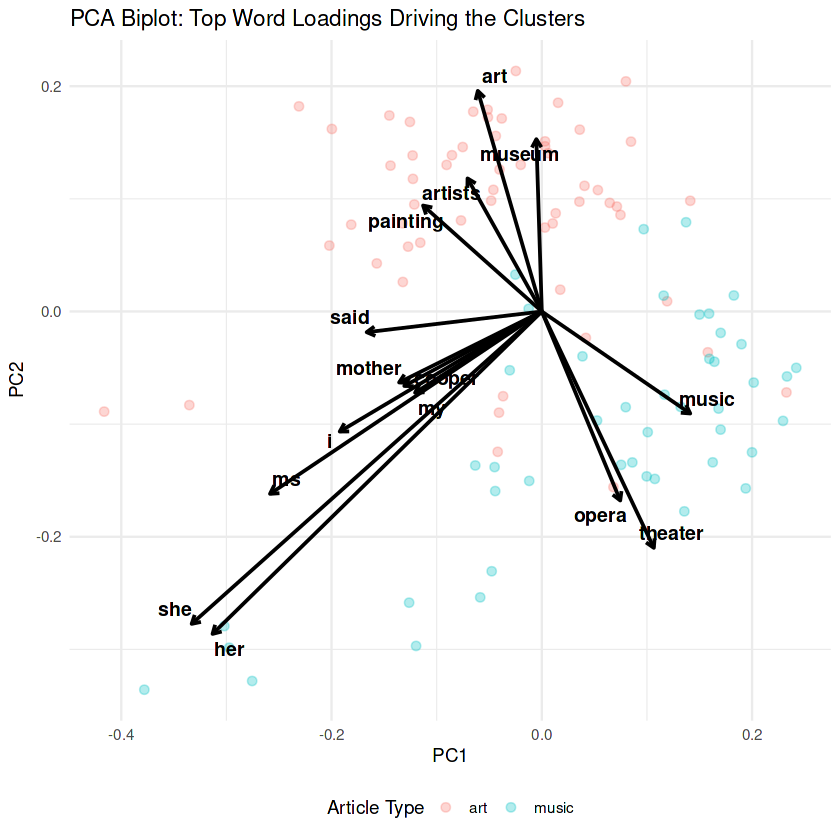

In [19]:
# Extract the rotation matrix (variable loadings)
loadings <- as.data.frame(pca_result$rotation[, 1:2])
loadings$Word <- rownames(loadings)

# Calculate the magnitude of each word's contribution to the 2D plane
loadings$Magnitude <- sqrt(loadings$PC1^2 + loadings$PC2^2)

# Select the top 15 words with the largest loadings
top_loadings <- loadings %>%
  arrange(desc(Magnitude)) %>%
  head(15)

# Scale factor to make the arrows visible on the same plot as the scores
# (Adjust the multiplier '5' if arrows are too small or too large)
scale_factor <- max(abs(pca_data$PC1)) / max(abs(top_loadings$PC1)) * 0.8

# Plot 2: Custom Biplot
plot2 <- ggplot() +
  # Plot the article points (faded for background context)
  geom_point(data = pca_data, aes(x = PC1, y = PC2, color = Article_Type), 
             alpha = 0.3, size = 2) +
  # Add the vectors (arrows) for the top words
  geom_segment(data = top_loadings, 
               aes(x = 0, y = 0, xend = PC1 * scale_factor, yend = PC2 * scale_factor),
               arrow = arrow(length = unit(0.2, "cm")), color = "black", linewidth = 0.8) +
  # Add the text labels for the words at the end of the arrows
  geom_text_repel(data = top_loadings, 
                  aes(x = PC1 * scale_factor, y = PC2 * scale_factor, label = Word),
                  color = "black", fontface = "bold", size = 4) +
  theme_minimal() +
  labs(title = "PCA Biplot: Top Word Loadings Driving the Clusters",
       x = "PC1",
       y = "PC2",
       color = "Article Type") +
  theme(legend.position = "bottom")

print(plot2)

III. Heart Disease Dataset Analysis Using Mosaic Plots and Cotabplots

In [20]:
library(tidyverse) 
library(vcd)

In [21]:
heart_data <- read.csv("/kaggle/input/datasets/ivancobarrubias/sa2-dsc1105/heart-1.csv", stringsAsFactors = TRUE)

# Convert the numerical target variable into an explicit factor for clean labels
heart_data$HeartDiseaseFactor <- factor(heart_data$HeartDisease, 
                                        levels = c(0, 1), 
                                        labels = c("Healthy", "Heart Disease"))

[1] "--- ST Slope vs Heart Disease Table ---"
      
       Healthy Heart Disease
  Down      14            49
  Flat      79           381
  Up       317            78
[1] "--- Exercise Angina vs Heart Disease Table ---"
   
    Healthy Heart Disease
  N     355           192
  Y      55           316
[1] "--- Resting ECG vs Heart Disease Table ---"
        
         Healthy Heart Disease
  LVH         82           106
  Normal     267           285
  ST          61           117


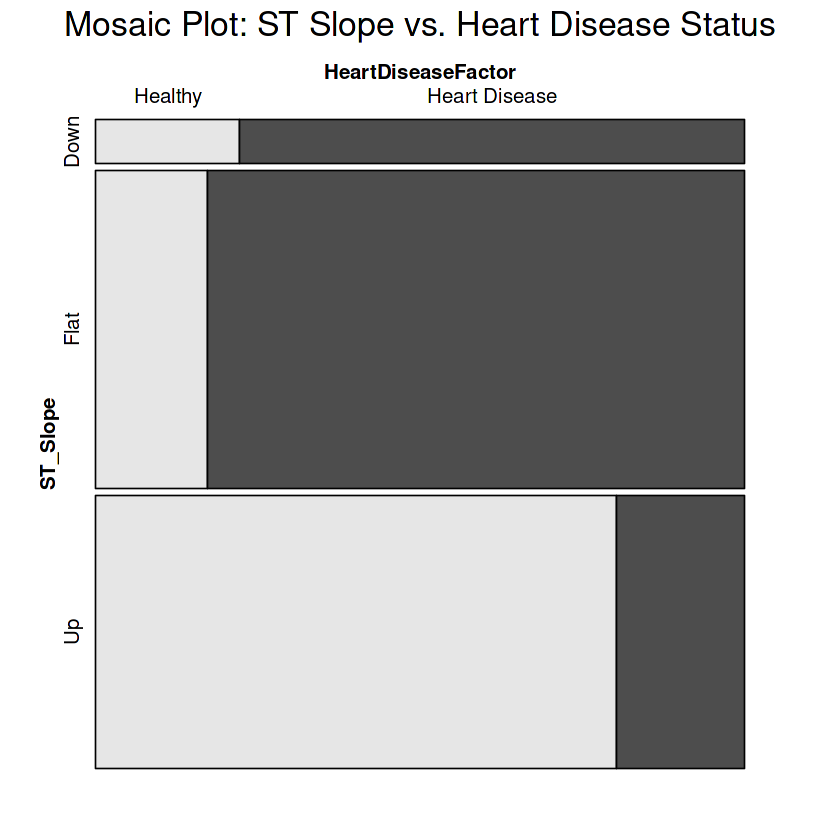

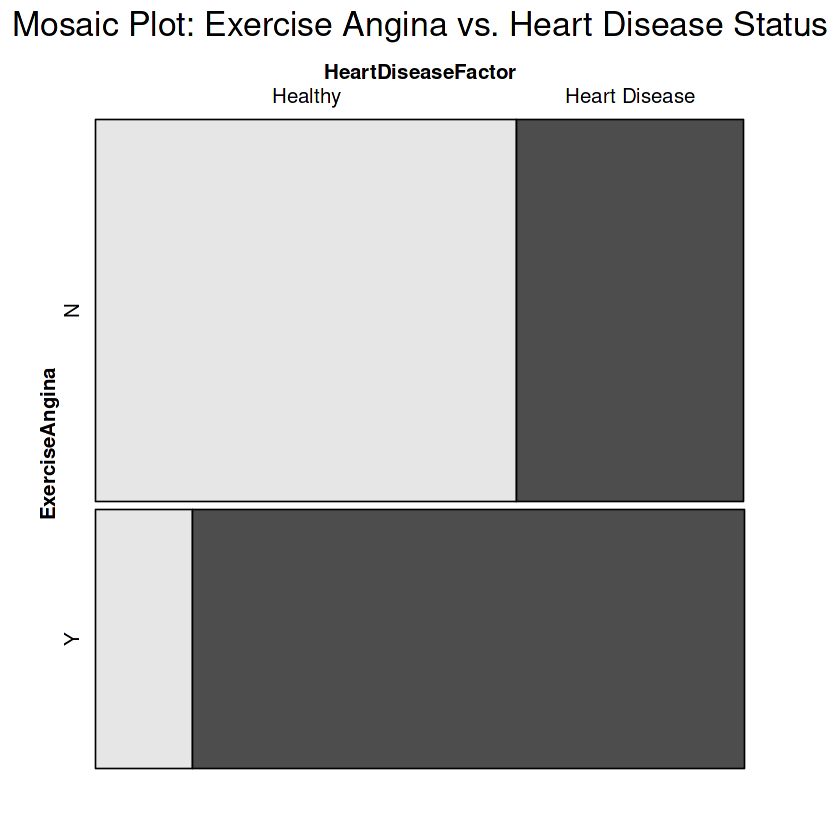

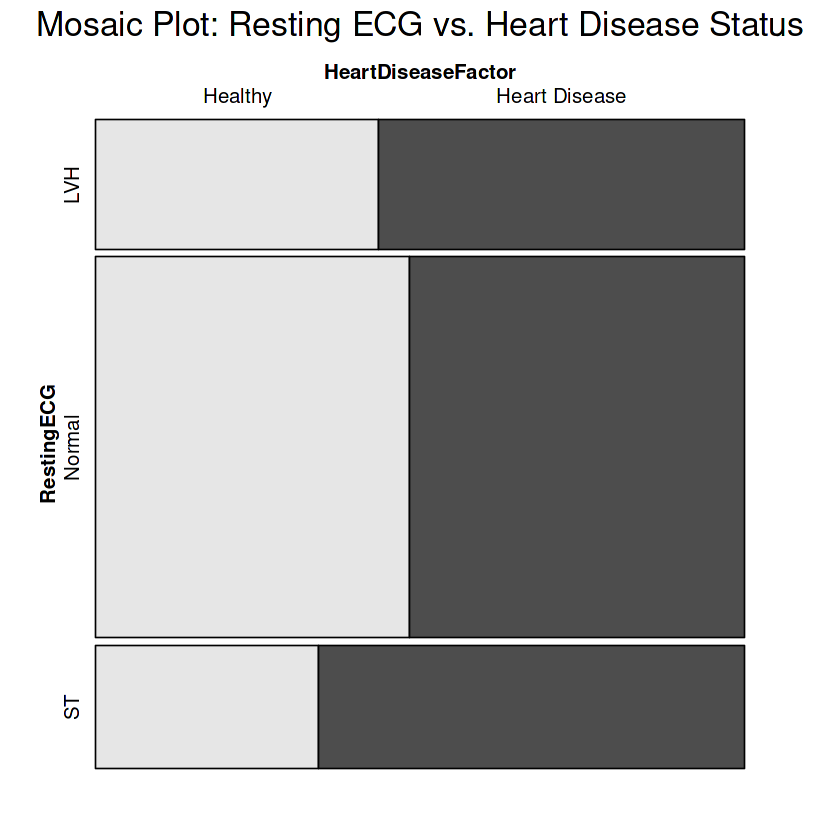

In [25]:
table_st <- table(heart_data$ST_Slope, heart_data$HeartDiseaseFactor)
table_angina <- table(heart_data$ExerciseAngina, heart_data$HeartDiseaseFactor)
table_ecg <- table(heart_data$RestingECG, heart_data$HeartDiseaseFactor)

print("--- ST Slope vs Heart Disease Table ---")
print(table_st)

print("--- Exercise Angina vs Heart Disease Table ---")
print(table_angina)

print("--- Resting ECG vs Heart Disease Table ---")
print(table_ecg)


# FIX: Removed legend = TRUE to prevent the internal strucplot/gp conflict.
# shade = TRUE will automatically draw both the color tile and its legend.

# 1A. ST Slope vs Heart Disease Mosaic Plot
vcd::mosaic(HeartDiseaseFactor ~ ST_Slope, data = heart_data, 
            shade = TRUE,
            main = "Mosaic Plot: ST Slope vs. Heart Disease Status")

# 1B. Exercise Angina vs Heart Disease Mosaic Plot
vcd::mosaic(HeartDiseaseFactor ~ ExerciseAngina, data = heart_data, 
            shade = TRUE,
            main = "Mosaic Plot: Exercise Angina vs. Heart Disease Status")

# 1C. Resting ECG vs Heart Disease Mosaic Plot
vcd::mosaic(HeartDiseaseFactor ~ RestingECG, data = heart_data, 
            shade = TRUE,
            main = "Mosaic Plot: Resting ECG vs. Heart Disease Status")

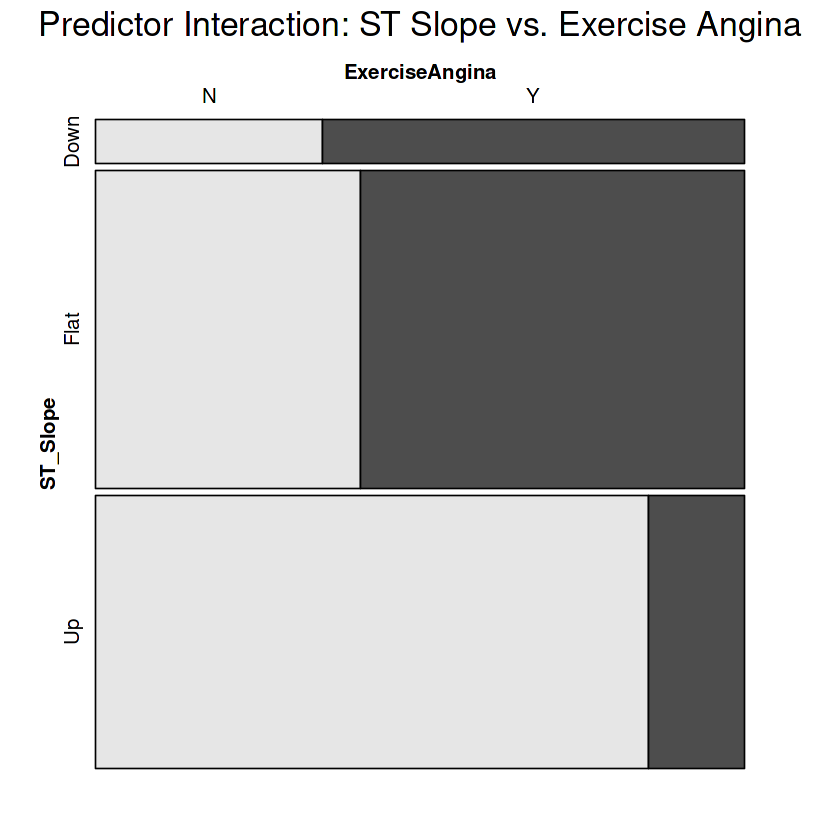

In [28]:
table_st_angina <- table(heart_data$ST_Slope, heart_data$ExerciseAngina)

vcd::mosaic(ExerciseAngina ~ ST_Slope, data = heart_data, 
            shade = TRUE,
            main = "Predictor Interaction: ST Slope vs. Exercise Angina")

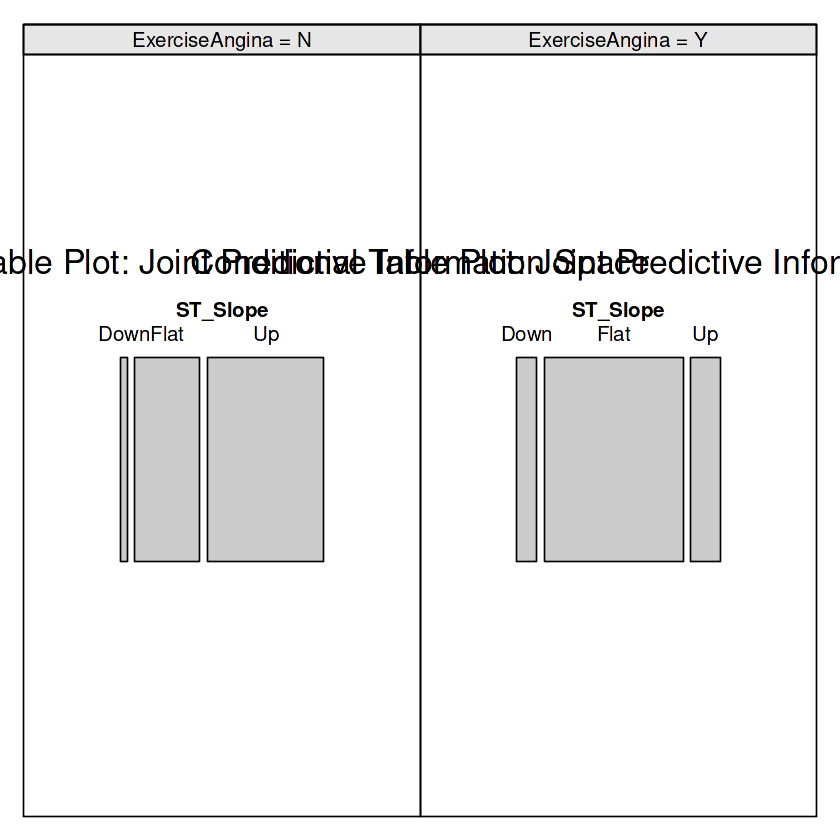

In [27]:
vcd::cotabplot(HeartDiseaseFactor ~ ST_Slope | ExerciseAngina, 
               data = heart_data, 
               panel = cotab_mosaic,   
               split_vertical = TRUE,  
               col = c("#4daf4a", "#e41a1c"), 
               main = "Conditional Table Plot: Joint Predictive Information Space")